In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('bank.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Data Understanding

In [ ]:
print("Shape:", df.shape)

Shape: (10000, 12)


In [ ]:
print("Info:")
df.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


# Data Quality Check

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [ ]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 0


# Data Cleaning

In [ ]:
df.drop('customer_id', axis=1, inplace=True)

In [ ]:
print("\nUnique values in categorical columns:")
for col in ['country','gender']:
    print(f"{col}: {df[col].unique()}")


Unique values in categorical columns:
country: ['France' 'Spain' 'Germany']
gender: ['Female' 'Male']


In [ ]:
print("\nTarget (loan_status) stats:")
print(df['churn'].describe())


Target (loan_status) stats:
count    10000.000000
mean         0.203700
std          0.402769
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: churn, dtype: float64


# Exploratory Data Analysis (EDA)

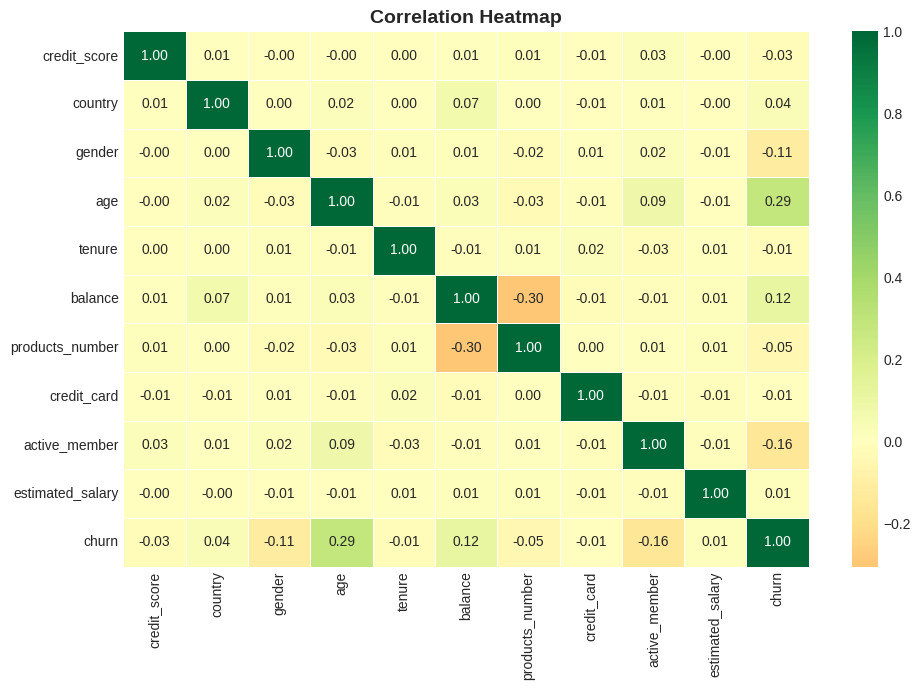

In [ ]:
df_num = df.copy()
df_num['gender']  = (df_num['gender'] == 'Male').astype(int)
df_num['country'] = df_num['country'].map({'France':0,'Germany':1,'Spain':2})

plt.figure(figsize=(10,7))
sns.heatmap(df_num.corr(),
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

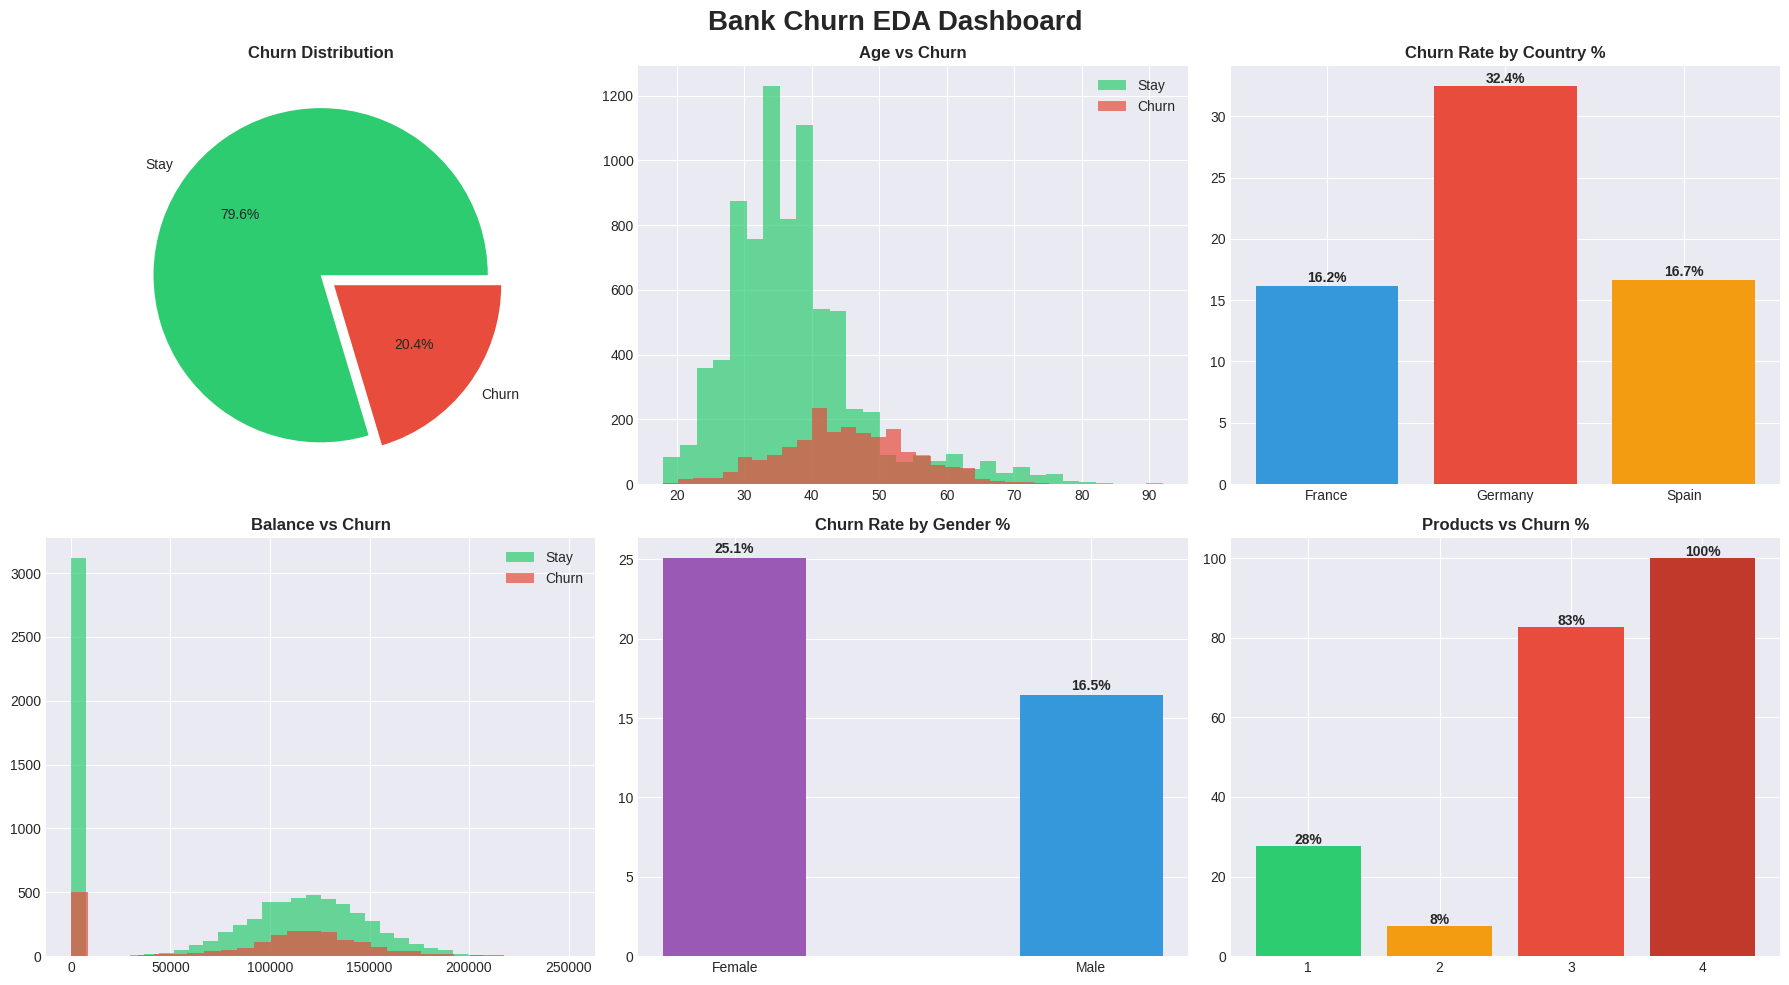

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bank Churn EDA Dashboard', fontsize=20, fontweight='bold')

# 1. Pie Chart
churn_counts = df['churn'].value_counts()
axes[0,0].pie(churn_counts.values,
              labels=['Stay', 'Churn'],
              colors=['#2ecc71','#e74c3c'],
              autopct='%1.1f%%',
              explode=(0, 0.1))
axes[0,0].set_title('Churn Distribution', fontweight='bold')

# 2. Age
stay  = df[df['churn']==0]
churn = df[df['churn']==1]
stay['age'].hist(bins=30, ax=axes[0,1], alpha=0.7, color='#2ecc71', label='Stay')
churn['age'].hist(bins=30, ax=axes[0,1], alpha=0.7, color='#e74c3c', label='Churn')
axes[0,1].set_title('Age vs Churn', fontweight='bold')
axes[0,1].legend()

# 3. Country
country_churn = df.groupby('country')['churn'].mean() * 100
axes[0,2].bar(country_churn.index, country_churn.values,
              color=['#3498db','#e74c3c','#f39c12'])
axes[0,2].set_title('Churn Rate by Country %', fontweight='bold')
for i, v in enumerate(country_churn.values):
    axes[0,2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 4. Balance
stay['balance'].hist(bins=30, ax=axes[1,0], alpha=0.7, color='#2ecc71', label='Stay')
churn['balance'].hist(bins=30, ax=axes[1,0], alpha=0.7, color='#e74c3c', label='Churn')
axes[1,0].set_title('Balance vs Churn', fontweight='bold')
axes[1,0].legend()

# 5. Gender
gender_churn = df.groupby('gender')['churn'].mean() * 100
axes[1,1].bar(gender_churn.index, gender_churn.values,
              color=['#9b59b6','#3498db'], width=0.4)
axes[1,1].set_title('Churn Rate by Gender %', fontweight='bold')
for i, v in enumerate(gender_churn.values):
    axes[1,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 6. Products
prod_churn = df.groupby('products_number')['churn'].mean() * 100
axes[1,2].bar(prod_churn.index.astype(str), prod_churn.values,
              color=['#2ecc71','#f39c12','#e74c3c','#c0392b'])
axes[1,2].set_title('Products vs Churn %', fontweight='bold')
for i, v in enumerate(prod_churn.values):
    axes[1,2].text(i, v+0.5, f'{v:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

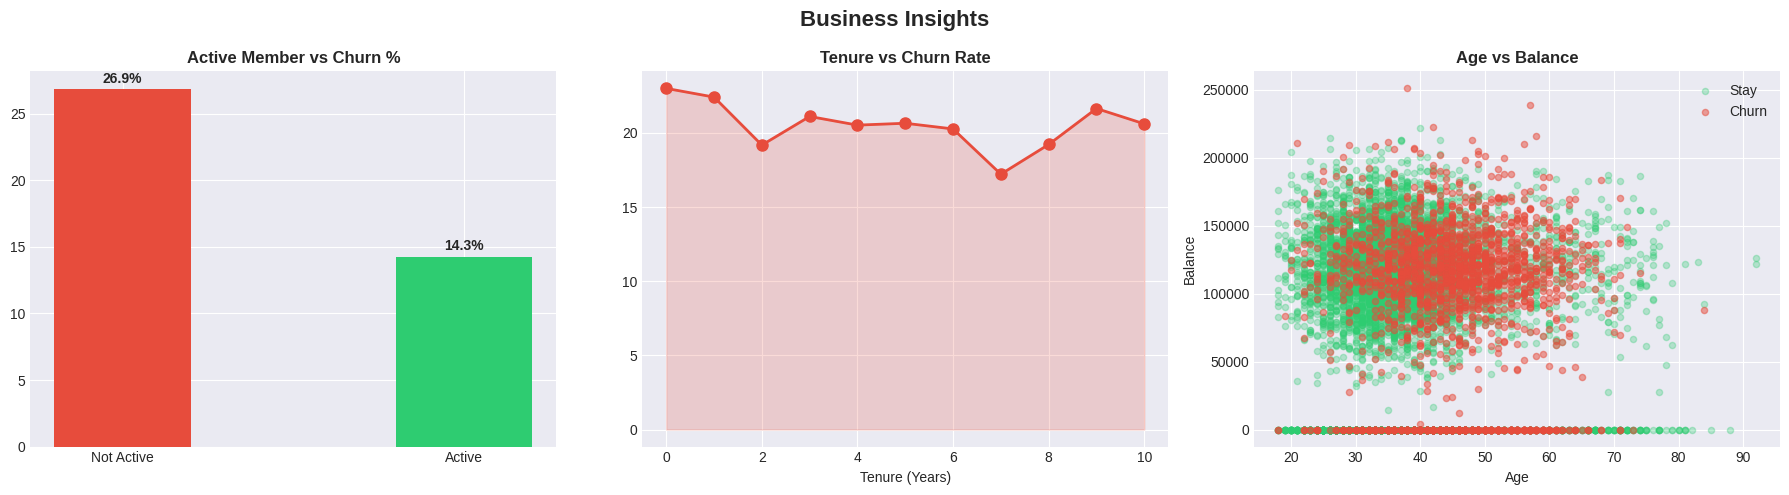

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Business Insights', fontsize=16, fontweight='bold')

stay  = df[df['churn']==0]
churn = df[df['churn']==1]

# 1. Active vs Churn
active_churn = df.groupby('active_member')['churn'].mean() * 100
axes[0].bar(['Not Active','Active'], active_churn.values,
            color=['#e74c3c','#2ecc71'], width=0.4)
axes[0].set_title('Active Member vs Churn %', fontweight='bold')
for i, v in enumerate(active_churn.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Tenure Line
tenure_churn = df.groupby('tenure')['churn'].mean() * 100
axes[1].plot(tenure_churn.index, tenure_churn.values,
             marker='o', color='#e74c3c', linewidth=2, markersize=8)
axes[1].fill_between(tenure_churn.index, tenure_churn.values,
                     alpha=0.2, color='#e74c3c')
axes[1].set_title('Tenure vs Churn Rate', fontweight='bold')
axes[1].set_xlabel('Tenure (Years)')

# 3. Age vs Balance Scatter
axes[2].scatter(stay['age'],  stay['balance'],
                alpha=0.3, color='#2ecc71', label='Stay', s=20)
axes[2].scatter(churn['age'], churn['balance'],
                alpha=0.5, color='#e74c3c', label='Churn', s=20)
axes[2].set_title('Age vs Balance', fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Balance')
axes[2].legend()

plt.tight_layout()
plt.show()

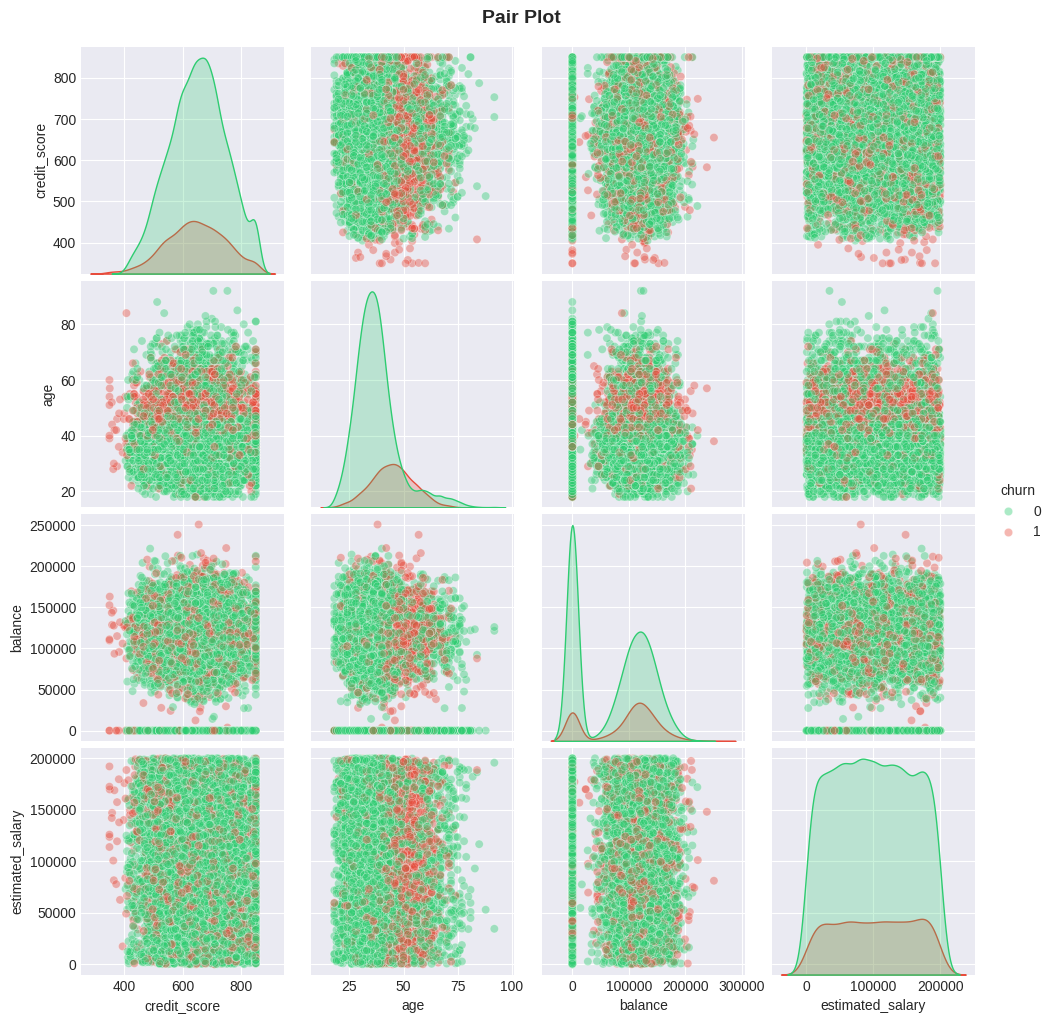

In [ ]:
cols = ['credit_score','age','balance','estimated_salary','churn']

sns.pairplot(df[cols],
             hue='churn',
             palette={0:'#2ecc71', 1:'#e74c3c'},
             diag_kind='kde',
             plot_kws={'alpha':0.4},
             height=2.5)

plt.suptitle('Pair Plot', y=1.02, fontsize=14, fontweight='bold')
plt.show()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


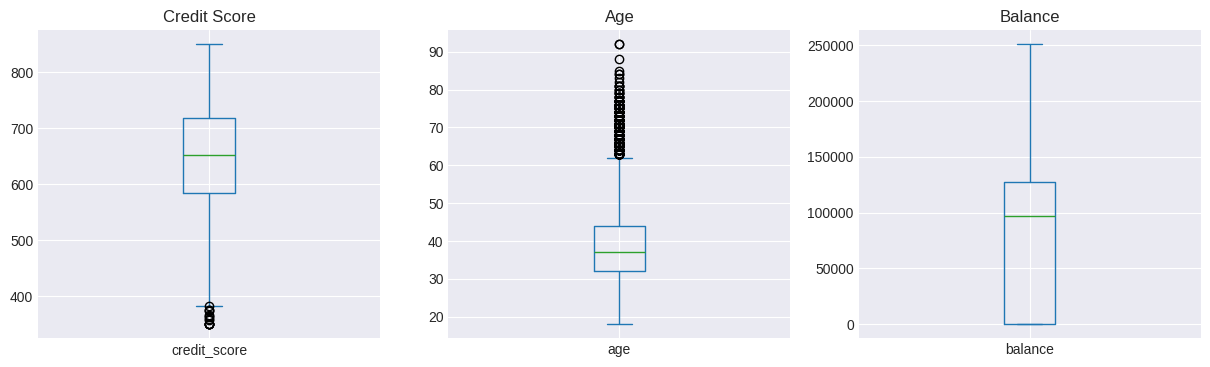

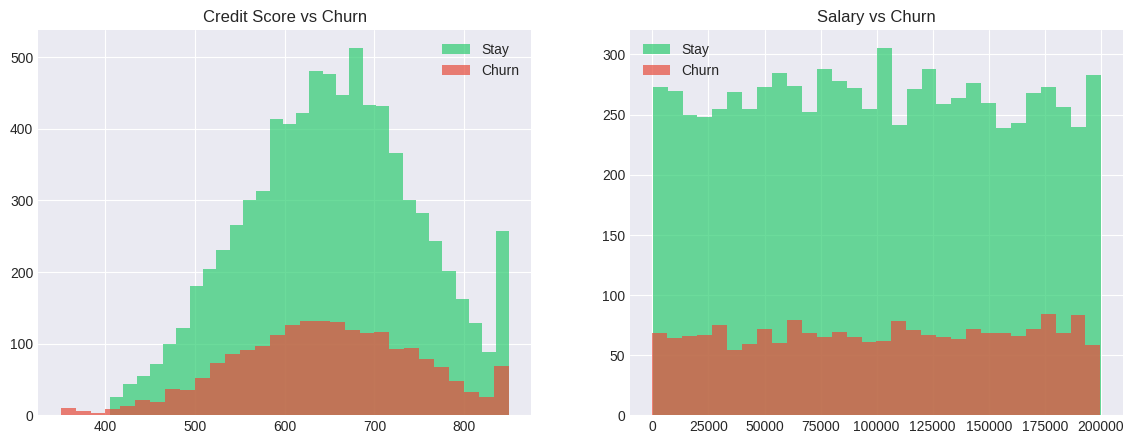

In [ ]:
# 1. Missing Values Check
print(df.isnull().sum())

# 2. Outliers Check
fig, axes = plt.subplots(1, 3, figsize=(15,4))
df['credit_score'].plot(kind='box', ax=axes[0], title='Credit Score')
df['age'].plot(kind='box', ax=axes[1], title='Age')
df['balance'].plot(kind='box', ax=axes[2], title='Balance')
plt.show()

# 3. Credit Score vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14,5))
stay  = df[df['churn']==0]
churn = df[df['churn']==1]

stay['credit_score'].hist(bins=30, ax=axes[0],
    alpha=0.7, color='#2ecc71', label='Stay')
churn['credit_score'].hist(bins=30, ax=axes[0],
    alpha=0.7, color='#e74c3c', label='Churn')
axes[0].set_title('Credit Score vs Churn')
axes[0].legend()

# 4. Salary vs Churn
stay['estimated_salary'].hist(bins=30, ax=axes[1],
    alpha=0.7, color='#2ecc71', label='Stay')
churn['estimated_salary'].hist(bins=30, ax=axes[1],
    alpha=0.7, color='#e74c3c', label='Churn')
axes[1].set_title('Salary vs Churn')
axes[1].legend()
plt.show()


In [ ]:
print(df['churn'].value_counts())

churn
0    7963
1    2037
Name: count, dtype: int64


# Data Preprocessing

In [ ]:
X = df.drop(columns=['churn'])
y = df.churn

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y_train.unique())

[0 1]


# PREPROCESSING PIPELINE

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Categorical columns: ['country', 'gender']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Fit + Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("\n✅ X_train_processed shape:", X_train_processed.shape)
print("✅ X_test_processed shape:", X_test_processed.shape)
print("\nFinal Feature Names:")
print(preprocessor.get_feature_names_out())


✅ X_train_processed shape: (8000, 11)
✅ X_test_processed shape: (2000, 11)

Final Feature Names:
['num__credit_score' 'num__age' 'num__tenure' 'num__balance'
 'num__products_number' 'num__credit_card' 'num__active_member'
 'num__estimated_salary' 'cat__country_Germany' 'cat__country_Spain'
 'cat__gender_Male']


In [ ]:
# --- Step 5: Final feature names dekho ---
print("\nFinal Feature Names:")
print(preprocessor.get_feature_names_out())


Final Feature Names:
['num__credit_score' 'num__age' 'num__tenure' 'num__balance'
 'num__products_number' 'num__credit_card' 'num__active_member'
 'num__estimated_salary' 'cat__country_Germany' 'cat__country_Spain'
 'cat__gender_Male']


# Model Building ANN

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# X_train_processed ki jagah X_train use karo
input_dim = X_train_processed.shape[1]
print("Input Dimension:", input_dim)

Input Dimension: 11


In [ ]:
# ============================================
# RETRAIN WITH CLASS WEIGHTS — Imbalance Fix
# ============================================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class weights calculate karo
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

# Naya model (same architecture)
model2 = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train WITH class_weight
history2 = model2.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,   # ← YEH NAYA HAI!
    verbose=1
)

Class Weights: {0: np.float64(0.6293266205160478), 1: np.float64(2.4330900243309004)}
Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6583 - loss: 0.5831 - val_accuracy: 0.7581 - val_loss: 0.4898
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7572 - loss: 0.4895 - val_accuracy: 0.7525 - val_loss: 0.4815
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7781 - loss: 0.4693 - val_accuracy: 0.7625 - val_loss: 0.4795
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7850 - loss: 0.4593 - val_accuracy: 0.7994 - val_loss: 0.4312
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.4517 - val_accuracy: 0.7675 - val_loss: 0.4627
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8022 - loss: 0.4452 - val_accuracy: 0.7875 - val_loss: 0.4363
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8030 - loss: 0.4436 - val_accuracy: 0.7856 - val_loss: 0.4423
Epoch 8/50
200/200

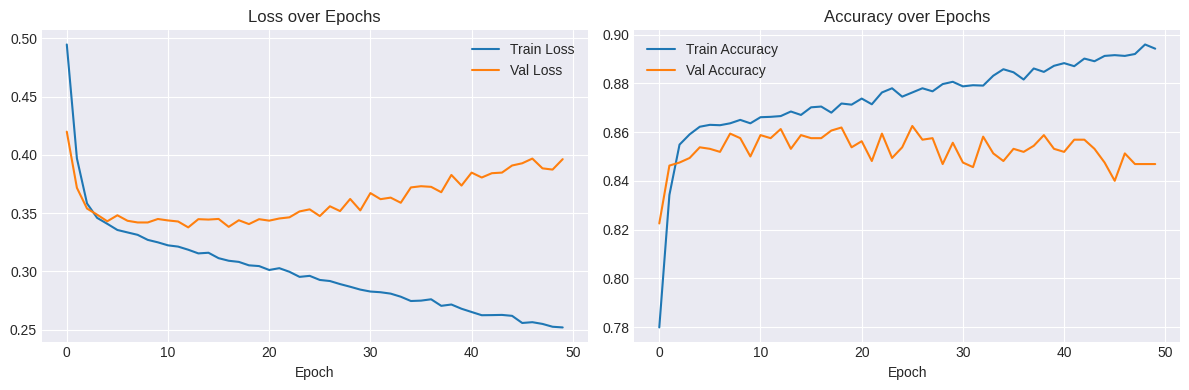

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
high_risk_customer = {
    'credit_score': 450,        # Low credit score
    'country': 'Germany',
    'gender': 'Female',
    'age': 55,                  # Older customer
    'tenure': 1,                # New customer (low loyalty)
    'balance': 150000.00,       # High balance (Germany often higher churn)
    'products_number': 1,       # Sirf 1 product
    'credit_card': 0,           # No credit card
    'active_member': 0,         # NOT active!
    'estimated_salary': 50000.00
}

print("TEST 1 — High Risk Customer:")
predict_churn(high_risk_customer)

TEST 1 — High Risk Customer:
Prediction: Will CHURN ⚠️
Churn Probability: 97.56%
----------------------------------------


('Will CHURN ⚠️', np.float32(0.9756173))

In [ ]:
# ============================================
# PREDICTION FUNCTION — UPDATED (model_v2)
# ============================================
def predict_churn_v2(customer_data):
    input_df = pd.DataFrame([customer_data])

    for col in ['country', 'gender']:
        input_df[col] = input_df[col].astype(str).str.strip()

    input_processed = preprocessor.transform(input_df)

    prob = model_v2.predict(input_processed, verbose=0)[0][0]  # ← model_v2!
    result = "Will CHURN ⚠️" if prob > 0.5 else "Will STAY ✅"

    print(f"Prediction: {result}")
    print(f"Churn Probability: {prob*100:.2f}%")
    print("-" * 40)
    return result, prob

In [ ]:
# Test 3 — Real row
sample = X_test.iloc[0].to_dict()
print("ACTUAL TRUE LABEL:", y_test.iloc[0])
predict_churn_v2(sample)

# Test 5 — Find churned customers
print("\nACTUAL CHURNED CUSTOMERS (with model_v2):")
churned_indices = y_test[y_test == 1].index[:3]
for idx in churned_indices:
    sample = X_test.loc[idx].to_dict()
    predict_churn_v2(sample)

ACTUAL TRUE LABEL: 0
Prediction: Will STAY ✅
Churn Probability: 8.79%
----------------------------------------

ACTUAL CHURNED CUSTOMERS (with model_v2):
Prediction: Will CHURN ⚠️
Churn Probability: 51.61%
----------------------------------------
Prediction: Will CHURN ⚠️
Churn Probability: 96.84%
----------------------------------------
Prediction: Will CHURN ⚠️
Churn Probability: 96.54%
----------------------------------------


In [ ]:
# ============================================
# PREDICTION FUNCTION — Bank Churn
# ============================================
import pandas as pd

def predict_churn(customer_data):
    """
    customer_data: dict with original feature names
    """
    input_df = pd.DataFrame([customer_data])

    # Spaces strip karo (safety)
    for col in ['country', 'gender']:
        input_df[col] = input_df[col].astype(str).str.strip()

    # Preprocessing apply karo
    input_processed = preprocessor.transform(input_df)

    # Prediction
    prob = model.predict(input_processed, verbose=0)[0][0]
    result = "Will CHURN ⚠️" if prob > 0.5 else "Will STAY ✅"

    print(f"Prediction: {result}")
    print(f"Churn Probability: {prob*100:.2f}%")
    print("-" * 40)
    return result, prob

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
📊 IMPROVED MODEL — TEST RESULTS
Accuracy: 0.7955

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.86      1607
           1       0.49      0.75      0.59       393

    accuracy                           0.80      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.80      0.81      2000



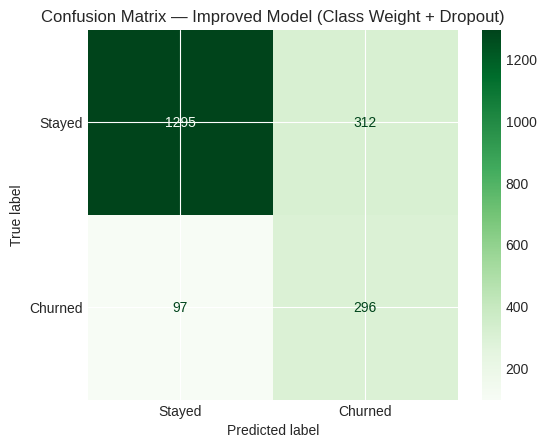

In [ ]:
# ============================================
# FINAL EVALUATION — IMPROVED MODEL
# ============================================
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_prob_v2 = model_v2.predict(X_test_processed)
y_pred_v2 = (y_pred_prob_v2 > 0.5).astype(int)

print("=" * 50)
print("📊 IMPROVED MODEL — TEST RESULTS")
print("=" * 50)
print("Accuracy:", accuracy_score(y_test, y_pred_v2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_v2))

cm2 = confusion_matrix(y_test, y_pred_v2)
ConfusionMatrixDisplay(cm2, display_labels=['Stayed', 'Churned']).plot(cmap='Greens')
plt.title('Confusion Matrix — Improved Model (Class Weight + Dropout)')
plt.show()

In [ ]:
low_risk_customer = {
    'credit_score': 750,        # High credit score
    'country': 'France',
    'gender': 'Male',
    'age': 35,
    'tenure': 8,                # Long-time customer
    'balance': 60000.00,
    'products_number': 2,
    'credit_card': 1,           # Has credit card
    'active_member': 1,         # Active member!
    'estimated_salary': 90000.00
}

print("TEST 2 — Low Risk Customer:")
predict_churn(low_risk_customer)

TEST 2 — Low Risk Customer:
Prediction: Will STAY ✅
Churn Probability: 13.86%
----------------------------------------


('Will STAY ✅', np.float32(0.13857809))

In [ ]:
import joblib

# Improved model save karo
model_v2.save('bank_churn_ann_model.h5')

# Preprocessor save karo
joblib.dump(preprocessor, 'bank_churn_preprocessor.pkl')

print("✅ Model saved!")
print("✅ Preprocessor saved!")

✅ Model saved!
✅ Preprocessor saved!
